# 查找算法实现

本实验实现穷举查找、二分查找、二叉查找树和哈希查找四种算法，并通过可视化界面演示。


## 一、构造测试数据

生成1000个有序整数作为测试数据。


数据规模: 1000
数据范围: [6, 9999]
测试目标(存在): 6622
测试目标(不存在): -1


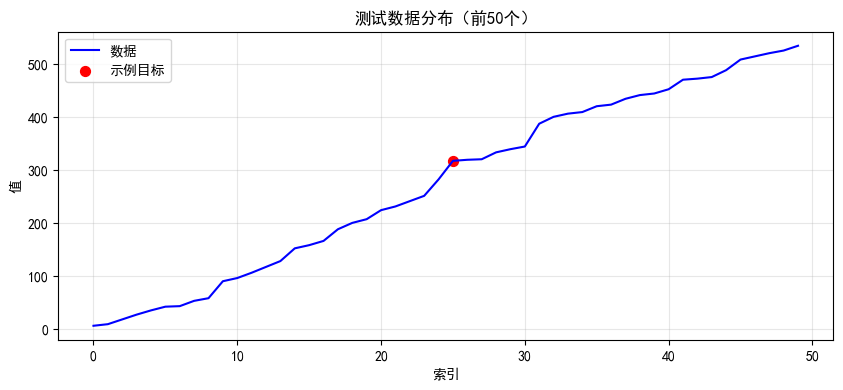

In [ ]:
import random
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

random.seed(42)

n = 1000
data = sorted(random.sample(range(n * 10), n))

target = data[random.randint(0, n-1)]
not_exist_target = -1

print(f"数据规模: {n}")
print(f"数据范围: [{min(data)}, {max(data)}]")
print(f"测试目标(存在): {target}")
print(f"测试目标(不存在): {not_exist_target}")

plt.figure(figsize=(10, 4))
plt.plot(data[:50], 'b-', label='数据')
plt.scatter(data.index(data[25]), data[25], c='red', s=50, marker='o', label='示例目标')
plt.title('测试数据分布（前50个）')
plt.xlabel('索引')
plt.ylabel('值')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 二、穷举查找

顺序遍历所有元素，直到找到目标或遍历结束。时间复杂度O(n)。


穷举查找测试：
目标 6622 (存在):
   索引: 646, 步数: 647, 耗时: 0.0000ms
目标 -1 (不存在):
   索引: -1, 步数: 1000, 耗时: 1.0116ms


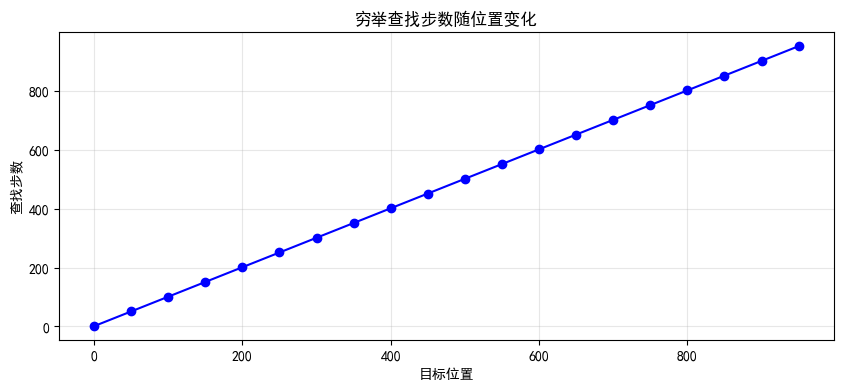

In [2]:
def linear_search(arr, target):
    """
    穷举查找（线性查找）
    参数：
        arr: 待查找的数组
        target: 查找目标
    返回：
        index: 目标在数组中的索引，未找到返回-1
        steps: 查找步数
    """
    steps = 0
    for i, val in enumerate(arr):
        steps += 1
        if val == target:
            return i, steps
    return -1, steps

import time

print("穷举查找测试：")
print("=" * 50)

start = time.time()
index, steps = linear_search(data, target)
end = time.time()
print(f"目标 {target} (存在):")
print(f"   索引: {index}, 步数: {steps}, 耗时: {(end-start)*1000:.4f}ms")

start = time.time()
index, steps = linear_search(data, not_exist_target)
end = time.time()
print(f"目标 {not_exist_target} (不存在):")
print(f"   索引: {index}, 步数: {steps}, 耗时: {(end-start)*1000:.4f}ms")

step_counts = []
for i in range(0, n, 50):
    _, steps = linear_search(data, data[i])
    step_counts.append((i, steps))

plt.figure(figsize=(10, 4))
plt.plot([x[0] for x in step_counts], [x[1] for x in step_counts], 'b-o')
plt.title('穷举查找步数随位置变化')
plt.xlabel('目标位置')
plt.ylabel('查找步数')
plt.grid(True, alpha=0.3)
plt.show()


## 三、二分查找

利用有序数组特性，每次将搜索范围缩小一半。时间复杂度O(log n)。


二分查找测试：
目标 6622 (存在):
   索引: 646, 步数: 10, 耗时: 0.0000ms
目标 -1 (不存在):
   索引: -1, 步数: 9, 耗时: 0.0000ms


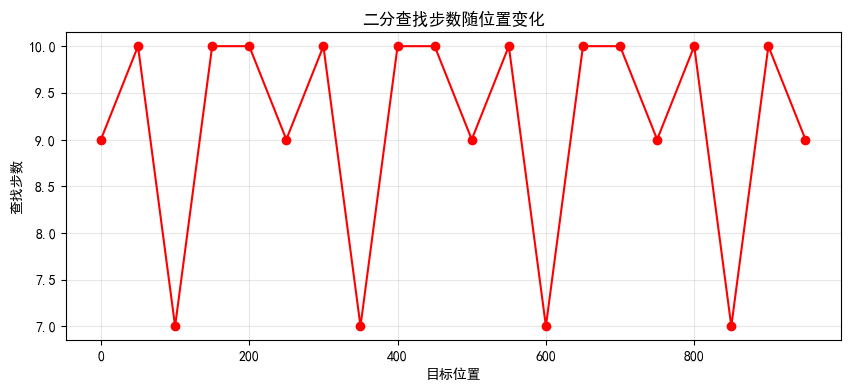

In [3]:
def binary_search(arr, target):
    """
    二分查找
    参数：
        arr: 待查找的有序数组
        target: 查找目标
    返回：
        index: 目标在数组中的索引，未找到返回-1
        steps: 查找步数
    """
    low = 0
    high = len(arr) - 1
    steps = 0
    
    while low <= high:
        steps += 1
        mid = (low + high) // 2
        if arr[mid] == target:
            return mid, steps
        elif arr[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    
    return -1, steps

print("二分查找测试：")
print("=" * 50)

start = time.time()
index, steps = binary_search(data, target)
end = time.time()
print(f"目标 {target} (存在):")
print(f"   索引: {index}, 步数: {steps}, 耗时: {(end-start)*1000:.4f}ms")

start = time.time()
index, steps = binary_search(data, not_exist_target)
end = time.time()
print(f"目标 {not_exist_target} (不存在):")
print(f"   索引: {index}, 步数: {steps}, 耗时: {(end-start)*1000:.4f}ms")

step_counts = []
for i in range(0, n, 50):
    _, steps = binary_search(data, data[i])
    step_counts.append((i, steps))

plt.figure(figsize=(10, 4))
plt.plot([x[0] for x in step_counts], [x[1] for x in step_counts], 'r-o')
plt.title('二分查找步数随位置变化')
plt.xlabel('目标位置')
plt.ylabel('查找步数')
plt.grid(True, alpha=0.3)
plt.show()


## 四、二叉查找树

构建二叉查找树，利用树结构实现高效查找。平均时间复杂度O(log n)。


二叉查找树测试：
目标 6622 (存在):
   找到: True, 步数: 647, 耗时: 0.0000ms
目标 -1 (不存在):
   找到: False, 步数: 2, 耗时: 0.0000ms

中序遍历验证（前10个）: [6, 9, 18, 27, 35, 42, 43, 53, 58, 90]


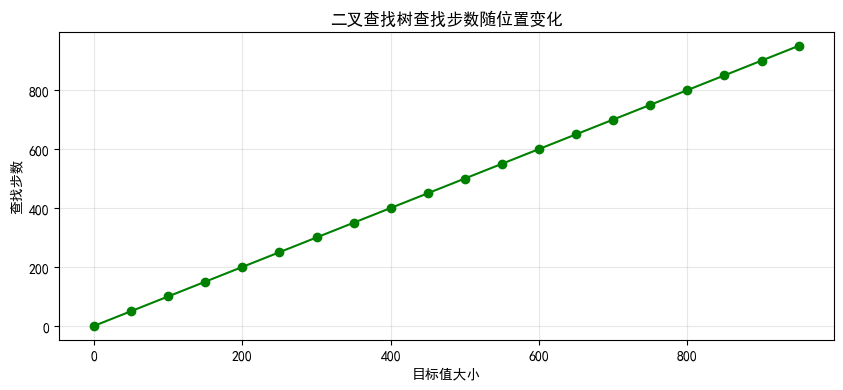

In [4]:
class TreeNode:
    """
    二叉树节点类
    """
    def __init__(self, value):
        self.value = value
        self.left = None
        self.right = None

class BinarySearchTree:
    """
    二叉查找树类
    """
    def __init__(self):
        self.root = None

    def insert(self, value):
        """
        插入节点
        """
        if self.root is None:
            self.root = TreeNode(value)
        else:
            self._insert_recursive(self.root, value)

    def _insert_recursive(self, node, value):
        if value < node.value:
            if node.left is None:
                node.left = TreeNode(value)
            else:
                self._insert_recursive(node.left, value)
        else:
            if node.right is None:
                node.right = TreeNode(value)
            else:
                self._insert_recursive(node.right, value)

    def search(self, target):
        """
        查找目标值
        返回：(是否找到, 查找步数)
        """
        return self._search_recursive(self.root, target, 0)

    def _search_recursive(self, node, target, steps):
        steps += 1
        if node is None:
            return False, steps
        if node.value == target:
            return True, steps
        elif target < node.value:
            return self._search_recursive(node.left, target, steps)
        else:
            return self._search_recursive(node.right, target, steps)

    def inorder_traversal(self, node=None):
        """
        中序遍历（升序）
        """
        if node is None:
            node = self.root
        result = []
        if node.left:
            result.extend(self.inorder_traversal(node.left))
        result.append(node.value)
        if node.right:
            result.extend(self.inorder_traversal(node.right))
        return result

bst = BinarySearchTree()
for val in data:
    bst.insert(val)

print("二叉查找树测试：")
print("=" * 50)

start = time.time()
found, steps = bst.search(target)
end = time.time()
print(f"目标 {target} (存在):")
print(f"   找到: {found}, 步数: {steps}, 耗时: {(end-start)*1000:.4f}ms")

start = time.time()
found, steps = bst.search(not_exist_target)
end = time.time()
print(f"目标 {not_exist_target} (不存在):")
print(f"   找到: {found}, 步数: {steps}, 耗时: {(end-start)*1000:.4f}ms")

print(f"\n中序遍历验证（前10个）: {bst.inorder_traversal()[:10]}")

step_counts = []
for i in range(0, n, 50):
    _, steps = bst.search(data[i])
    step_counts.append((i, steps))

plt.figure(figsize=(10, 4))
plt.plot([x[0] for x in step_counts], [x[1] for x in step_counts], 'g-o')
plt.title('二叉查找树查找步数随位置变化')
plt.xlabel('目标值大小')
plt.ylabel('查找步数')
plt.grid(True, alpha=0.3)
plt.show()


## 五、哈希查找

利用哈希表实现O(1)平均时间复杂度的查找。


哈希查找测试：
目标 6622 (存在):
   找到: True, 步数: 4, 耗时: 0.0000ms
目标 -1 (不存在):
   找到: False, 步数: 7, 耗时: 0.0000ms


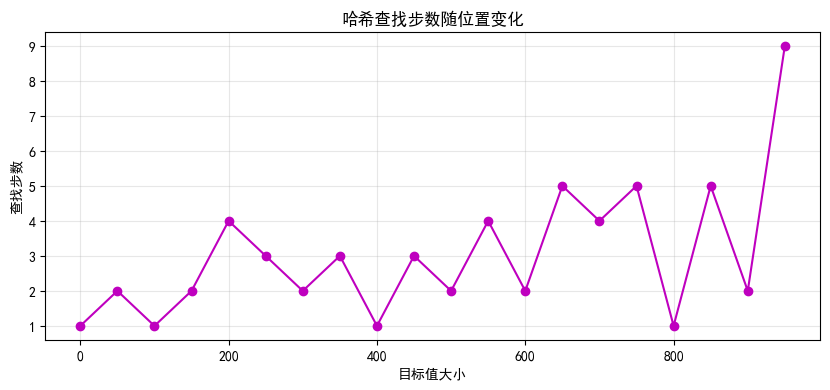

In [5]:
class HashTable:
    """
    哈希表类（链式法解决冲突）
    """
    def __init__(self, size=100):
        self.size = size
        self.table = [[] for _ in range(size)]

    def _hash(self, value):
        """
        哈希函数
        """
        return hash(value) % self.size

    def insert(self, value):
        """
        插入值
        """
        index = self._hash(value)
        if value not in self.table[index]:
            self.table[index].append(value)

    def search(self, target):
        """
        查找目标值
        返回：(是否找到, 查找步数)
        """
        index = self._hash(target)
        steps = 0
        for val in self.table[index]:
            steps += 1
            if val == target:
                return True, steps
        return False, steps

hash_table = HashTable(size=200)
for val in data:
    hash_table.insert(val)

print("哈希查找测试：")
print("=" * 50)

start = time.time()
found, steps = hash_table.search(target)
end = time.time()
print(f"目标 {target} (存在):")
print(f"   找到: {found}, 步数: {steps}, 耗时: {(end-start)*1000:.4f}ms")

start = time.time()
found, steps = hash_table.search(not_exist_target)
end = time.time()
print(f"目标 {not_exist_target} (不存在):")
print(f"   找到: {found}, 步数: {steps}, 耗时: {(end-start)*1000:.4f}ms")

step_counts = []
for i in range(0, n, 50):
    _, steps = hash_table.search(data[i])
    step_counts.append((i, steps))

plt.figure(figsize=(10, 4))
plt.plot([x[0] for x in step_counts], [x[1] for x in step_counts], 'm-o')
plt.title('哈希查找步数随位置变化')
plt.xlabel('目标值大小')
plt.ylabel('查找步数')
plt.grid(True, alpha=0.3)
plt.show()


## 六、四种查找算法对比

对比四种查找算法的性能表现。


四种查找算法性能对比：
算法         平均耗时(ms)        平均步数      
------------------------------------------------------------
穷举查找       0.0643          471.76    
二分查找       0.0151          8.75      
二叉查找树      0.4043          521.17    
哈希查找       0.0051          3.30      


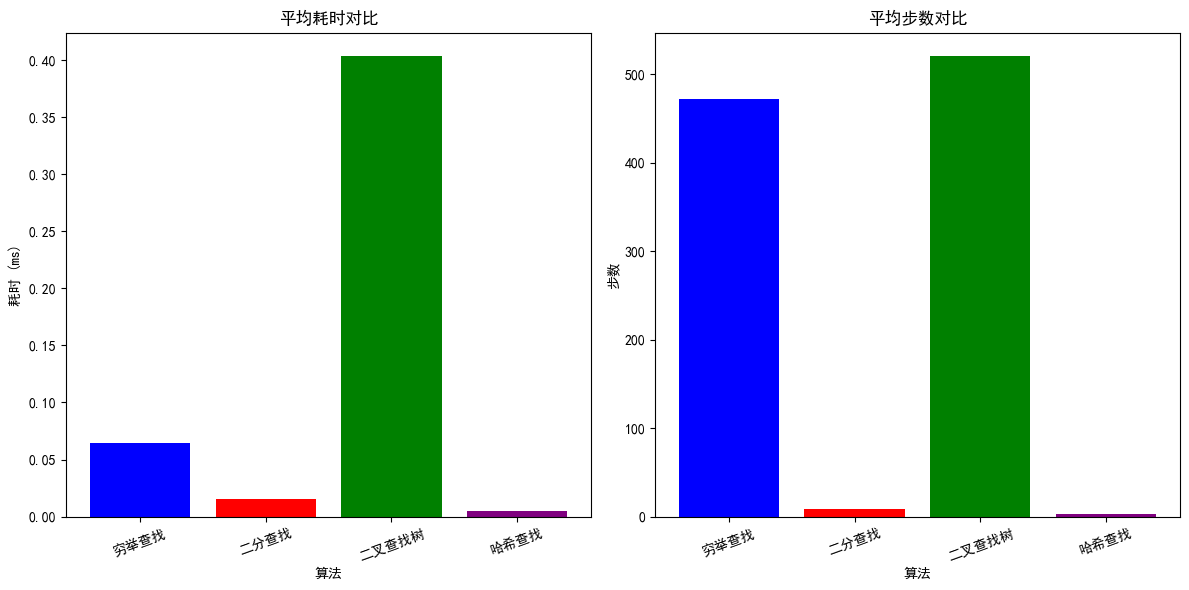


算法特性总结：
算法         时间复杂度           空间复杂度           适用场景                
------------------------------------------------------------
穷举查找       O(n)            O(1)            无序数据、小规模            
二分查找       O(log n)        O(1)            有序数组、静态数据           
二叉查找树      O(log n)        O(n)            动态插入删除              
哈希查找       O(1)            O(n)            频繁查找、大数据量           


In [6]:
algorithms = {
    '穷举查找': linear_search,
    '二分查找': binary_search,
    '二叉查找树': lambda arr, target: bst.search(target),
    '哈希查找': lambda arr, target: hash_table.search(target)
}

results = {}

for algo_name, algo_func in algorithms.items():
    times = []
    step_list = []
    for _ in range(100):
        test_target = data[random.randint(0, n-1)]
        start = time.time()
        result = algo_func(data, test_target)
        end = time.time()
        times.append(end - start)
        step_list.append(result[1])
    results[algo_name] = {
        'avg_time': sum(times) / len(times) * 1000,
        'avg_steps': sum(step_list) / len(step_list)
    }

print("四种查找算法性能对比：")
print("=" * 60)
print(f"{'算法':<10} {'平均耗时(ms)':<15} {'平均步数':<10}")
print("-" * 60)
for algo_name, stats in results.items():
    print(f"{algo_name:<10} {stats['avg_time']:<15.4f} {stats['avg_steps']:<10.2f}")

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.bar(results.keys(), [stats['avg_time'] for stats in results.values()], color=['blue', 'red', 'green', 'purple'])
plt.title('平均耗时对比')
plt.xlabel('算法')
plt.ylabel('耗时 (ms)')
plt.xticks(rotation=20)

plt.subplot(1, 2, 2)
plt.bar(results.keys(), [stats['avg_steps'] for stats in results.values()], color=['blue', 'red', 'green', 'purple'])
plt.title('平均步数对比')
plt.xlabel('算法')
plt.ylabel('步数')
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

print("\n算法特性总结：")
print("=" * 60)
print(f"{'算法':<10} {'时间复杂度':<15} {'空间复杂度':<15} {'适用场景':<20}")
print("-" * 60)
print(f"{'穷举查找':<10} {'O(n)':<15} {'O(1)':<15} {'无序数据、小规模':<20}")
print(f"{'二分查找':<10} {'O(log n)':<15} {'O(1)':<15} {'有序数组、静态数据':<20}")
print(f"{'二叉查找树':<10} {'O(log n)':<15} {'O(n)':<15} {'动态插入删除':<20}")
print(f"{'哈希查找':<10} {'O(1)':<15} {'O(n)':<15} {'频繁查找、大数据量':<20}")
